# ***Machine Learning — Assignment 2***

***`========== Multiple Linear Regression & Logistic Regression =========`***

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ***`PART 1 — Dataset Loading & Preprocessing`***

## ***`1.1 Load Dataset`***

In [ ]:
# Load dataset
df = pd.read_csv("Housing.csv")

In [ ]:
# Display First 5 Rows
print("First 5 Rows: ")
print(df.head())

First 5 Rows: 
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [ ]:
# Dataset shape
print("\nDataset shape:", df.shape)


Dataset shape: (545, 13)


In [ ]:
# Basic statistics
print("\nDataset statistics:")
print(df.describe())


Dataset statistics:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


## ***1.2 Preprocessing***

### ***`a) Handle Missing Values `***

In [ ]:
# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
# Fill numeric missing values with mean
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

In [ ]:
# Drop rows with more than 30% missing values
threshold = int(0.7 * df.shape[1])
df = df.dropna(thresh=threshold)

### ***`Encode Categorical Variables`***

Dataset contains categorical features such as:
*   mainroad
*   guestroom
*   basement
*   hotwaterheating
*   airconditioning
*   prefarea
*   furnishingstatus

These are strings, but my regression models require numerical matrices because the hypothesis is: h(x)=Xθ

Matrix multiplication cannot work with text values.
Therefore categorical variables must be converted into numbers.

So this step is required:

What it does:
*   Original <-----------> Encoded
*   yes	<---------------> 1
*   no <---------------->	0
*   furnished	<---------> 2
*   semi-furnished	<---> 1
*   unfurnished <------>	0


In [ ]:
# Label encode categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category').cat.codes

### ***`Separate Features and Target`***

The assignment requires separating:

Features (X):
All input variables

Examples:
*   furnishingstatus
*   parking
*   bathrooms
*   bedrooms
*   area

Target (y):
The value we want to predict:

*   price

So:

X = all columns except price

y = price column

.reshape(-1,1) is Used because:

y = df["price"].values.reshape(-1,1)

Without reshape:

y shape = (545,)

But gradient descent requires:

y shape = (545,1)

Because:
Xθ−y

must have matching dimensions.

If we forget this than we will get this type of error

*   TypeError: can't multiply sequence by non-int
*   ValueError: shapes not aligned

In [ ]:
X = df.drop("price", axis=1).values
y = df["price"].values.reshape(-1,1)

### ***`b) Feature Scaling`***

In [ ]:
# Z-Score Standardisation
def zscore_normalize(X):
    """
    Standardize features using Z-score normalization.

    Parameters:
    X : numpy array (features)

    Returns:
    X_scaled : normalized features
    mu : mean of each feature
    sigma : standard deviation of each feature
    """

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_scaled = (X - mu) / sigma

    return X_scaled, mu, sigma


X_scaled, mu, sigma = zscore_normalize(X)

### ***`c) Train / Test Split `***

In [ ]:
def train_test_split_manual(X, y, test_ratio=0.2):
    """
    Manually split dataset into train and test sets.
    Returns:
    X_train, X_test, y_train, y_test
    """
    m = X.shape[0]
    indices = np.arange(m)
    np.random.shuffle(indices)
    test_size = int(m * test_ratio)
    test_idx = indices[:test_size]
    train_idx = indices[test_size:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx], train_idx, test_idx

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split_manual(X_scaled, y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 436
Testing samples: 109


# ***`Part 2: Multiple Linear Regression`***

## ***`2.1 Design Matrix`***

In [ ]:
def add_bias(X):
    """
    Add column of ones for bias term.
    """

    ones = np.ones((X.shape[0],1))
    return np.hstack((ones, X))


X_train_b = add_bias(X_train)
X_test_b = add_bias(X_test)

## ***`2.2 Hypothesis Function`***

In [ ]:
def hypothesis(X, theta):
    """
    Compute prediction values.

    h(x) = Xθ
    """
    return X.dot(theta)

## ***`2.3 Cost Function (MSE)`***

In [ ]:
def compute_cost(X, y, theta):
    """
    Compute Mean Squared Error cost.
    """

    m = len(y)

    predictions = hypothesis(X, theta)

    cost = (1/(2*m)) * np.sum((predictions - y)**2)

    return cost

## ***`2.4 Gradient Descent`***

In [ ]:
def gradient_descent(X, y, alpha=0.01, iterations=1000):
    """
    Perform gradient descent optimization.

    Returns:
    theta
    cost_history
    """

    m,n = X.shape
    theta = np.zeros((n,1))

    cost_history = []

    for i in range(iterations):

        predictions = hypothesis(X, theta)

        gradients = (1/m) * X.T.dot(predictions - y)

        theta = theta - alpha * gradients

        cost = compute_cost(X,y,theta)

        cost_history.append(cost)

    return theta, cost_history


theta_mlr, mlr_cost = gradient_descent(X_train_b, y_train)

print("Final Theta values:\n", theta_mlr)
print("Final Training Cost:", mlr_cost[-1])

Final Theta values:
 [[4753634.64481116]
 [ 493372.34085944]
 [ 110799.28537286]
 [ 548266.09380512]
 [ 375812.02283132]
 [ 137041.62430053]
 [ 106133.30179929]
 [ 158176.73372353]
 [ 184062.45733473]
 [ 398675.82995532]
 [ 255608.36071944]
 [ 262611.43113122]
 [-133703.42001276]]
Final Training Cost: 555003676273.1981


## ***`Test MSE`***

In [ ]:
# Test Prediction
test_predictions = hypothesis(X_test_b, theta_mlr)
# Test Mean-Square-Error
test_mse = np.mean((test_predictions - y_test)**2)
# Display Mean-Square-Error
print("Test MSE:", test_mse)

Test MSE: 1174801187734.7249


# ***`Part 3: Logistic Regression (Classification)`***

## ***`3.1 Dataset Preparation for Classification`***

### ***`a) Create Binary Target`***

In [ ]:
median_price = np.median(df["price"])

### ***`b) Furnishing Status`***

In [ ]:
y_class_all = (df["price"] > median_price).astype(int).values.reshape(-1,1)

### ***`c) Train Test Split for Classification`***

In [ ]:
# Use the stored indices to split
y_train_c = y_class_all[train_idx]
y_test_c = y_class_all[test_idx]

# Features are already scaled and split: X_train, X_test from Part 1
X_train_c = add_bias(X_train)
X_test_c = add_bias(X_test)

## ***`3.2 Sigmoid Function`***

In [ ]:
def sigmoid(z):
    """
    Sigmoid activation function.
    """

    return 1 / (1 + np.exp(-z))


# Verification
print(sigmoid(0))
print(sigmoid(-100))
print(sigmoid(100))

0.5
3.7200759760208356e-44
1.0


## ***`3.3 Cost Function — Binary Cross-Entropy`***

In [ ]:
def logistic_cost(X, y, theta):
    """
    Compute Binary Cross Entropy cost.
    """

    m = len(y)

    epsilon = 1e-8

    h = sigmoid(X.dot(theta))

    cost = -(1/m)*np.sum(
        y*np.log(h+epsilon)+(1-y)*np.log(1-h+epsilon)
    )

    return cost

## ***`3.4 Gradient Descent for Logistic Regression`***

In [ ]:
def logistic_gradient_descent(X, y, alpha=0.01, iterations=1000):

    m,n = X.shape

    theta = np.zeros((n,1))

    cost_history = []

    for i in range(iterations):

        h = sigmoid(X.dot(theta))

        gradient = (1/m)*X.T.dot(h - y)

        theta = theta - alpha*gradient

        cost = logistic_cost(X,y,theta)

        cost_history.append(cost)

    return theta, cost_history


theta_lr1, cost_lr1 = logistic_gradient_descent(X_train_c,y_train_c,0.01)
theta_lr2, cost_lr2 = logistic_gradient_descent(X_train_c,y_train_c,0.1)

## ***` 3.5 Predictions & Evaluation`***

### ***` a) Classification Accuracy`***

In [ ]:
def predict(X, theta):
    """
    Predict class labels using threshold 0.5
    """

    probs = sigmoid(X.dot(theta))

    return (probs >= 0.5).astype(int)


y_pred = predict(X_test_c, theta_lr1)

accuracy = np.mean(y_pred == y_test_c)

print("Accuracy:", accuracy)

Accuracy: 0.8165137614678899


### ***`b) Confusion Matrix`***

In [ ]:
def confusion_matrix_manual(y_true, y_pred):

    TP = np.sum((y_true==1) & (y_pred==1))
    TN = np.sum((y_true==0) & (y_pred==0))
    FP = np.sum((y_true==0) & (y_pred==1))
    FN = np.sum((y_true==1) & (y_pred==0))

    return np.array([[TP,FP],
                     [FN,TN]])


cm = confusion_matrix_manual(y_test_c,y_pred)

print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[41  4]
 [16 48]]


# ***`Part 4: Comparison & Visualization `***

## ***`4.1 MLR Learning Curve`***

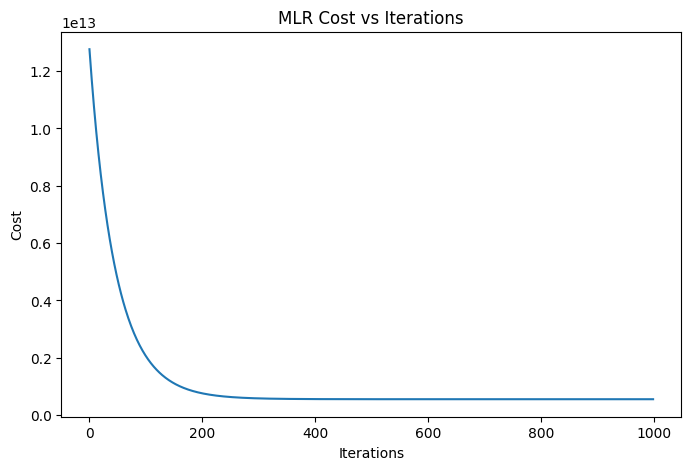

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(mlr_cost)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("MLR Cost vs Iterations")

plt.show()

## ***`4.2 Logistic Regression Cost Curve`***

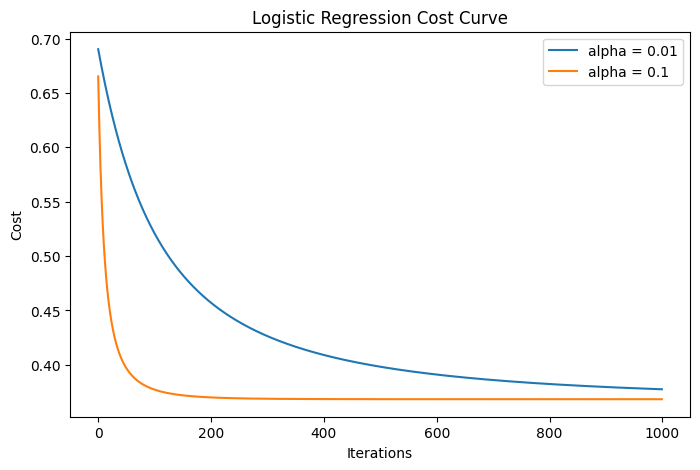

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cost_lr1,label="alpha = 0.01")
plt.plot(cost_lr2,label="alpha = 0.1")

plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.title("Logistic Regression Cost Curve")

plt.legend()

plt.show()

***`Which learning rate converges better?`***

*`From the cost curves plotted in section 4.2, we see that with α = 0.1 the cost drops very quickly in the first few iterations and reaches a lower value faster than with α = 0.01. However, α = 0.1 shows some oscillations, while α = 0.01 decreases smoothly but more slowly. In this case, α = 0.1 converges to a similar final cost in fewer iterations, so it is more efficient. The reason is that a larger learning rate takes bigger steps toward the minimum, but if it is too large it might overshoot; here 0.1 is still safe and speeds up convergence.`*

## ***`4.3 Confusion Matrix Heatmap`***

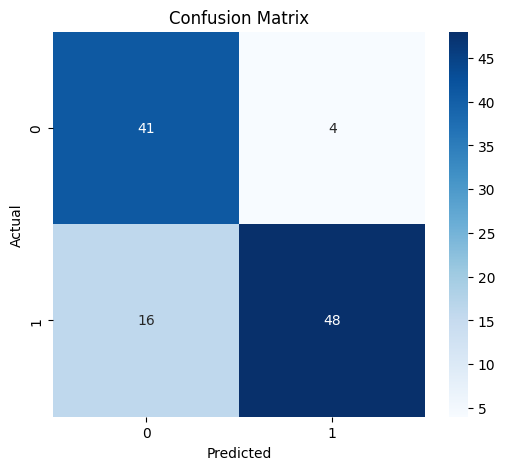

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

***`Interpretation of the Confusion Matrix`***

True Positives (TP): 41 expensive houses correctly classified as expensive.

True Negatives (TN): 48 affordable houses correctly classified as affordable.

False Positives (FP): 4 affordable houses incorrectly labelled as expensive.

False Negatives (FN): 16 expensive houses incorrectly labelled as affordable.

The model performs slightly better at identifying affordable houses (higher TN) but has a few false negatives. Overall accuracy is 81.65%. The heatmap shows that most errors are false negatives, meaning the model tends to miss some expensive houses rather than overpredict them.